# Лабораторная работа 1: CV

## Задание на Пятерку (Проведение исследований с моделями классификации)

### 1. Выбор начальных условий

- Название датасета: DeFungi: Microscopic Fungi Image Classification
- Ссылка: https://www.kaggle.com/datasets/joebeachcapital/defungi
- Тип задачи: Мультиклассовая классификация
- Описание: набор данных для прямого микологического исследования микроскопических изображений грибов. Изображения взяты из поверхностных грибковых инфекций, вызванных дрожжами, плесенью или дерматофитными грибами. Изображения разделены на пять классов. Датасет содержит более 9000 изображений.
- Практическая задача: Классификация грибковых инфекций помогает ускорить первичную диагностику в клинической микологии. Это будет актуально для лабораторий с высокой нагрузкой или ограниченным доступом к экспертам, модель может работать как второе мнение и отсеивать очевидные случаи.

Выбранные метрики качества:
- Accuracy: Базовая метрика для анализа точности предсказаний
- F1-macro: Учитывает все классы одинаково (модель не может получить высокий балл, просто научившись определять только популярные классы и игнорируя редкие)
- Confusion Matrix: Показывает, какие классы модель путает между собой

## 2. Создание бейзлайна и оценка качества

Беру модели из torchvision с предобученными весами:
- ResNet-18: свёрточная
- ViT-B/16: трансформерная

In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub

DATA_DIR = kagglehub.dataset_download("joebeachcapital/defungi")
print(f"Датасет загружен в: {DATA_DIR}")

100%|██████████| 149M/149M [00:04<00:00, 38.0MB/s]

Extracting files...


Датасет загружен в: /root/.cache/kagglehub/datasets/joebeachcapital/defungi/versions/1


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms, models

In [5]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

IMG_SIZE = 224
BATCH_SIZE = 32

In [6]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cuda


In [7]:
# Трансформации
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [8]:
# Загружаем датасет без трансформаций
full_ds = datasets.ImageFolder(root=DATA_DIR, transform=None)
classes = full_ds.classes
num_classes = len(classes)

# Разделение на train val
indices = list(range(len(full_ds)))
random.shuffle(indices)
split = int(0.8 * len(full_ds))
train_indices = indices[:split]
val_indices = indices[split:]

class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

# Создаём train и val датасеты с нужными трансформациями
train_ds = TransformedSubset(Subset(full_ds, train_indices), transform=train_tf)
val_ds = TransformedSubset(Subset(full_ds, val_indices),   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Классы: {classes} ({num_classes})")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Классы: ['H1', 'H2', 'H3', 'H5', 'H6'] (5)
Train: 7291, Val: 1823


Создаем модель с заменой последнего слоя, обучаем и возвращаем лучшую модель по accuracy на валидации

In [9]:
# Возвращает модель с предобученными весами
def get_model(name, num_classes, pretrained=True):
    if name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif name == "vit_b_16":
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT if pretrained else None)
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_classes)
    return model

# Одна эпоха обучения
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

# Возвращает accuracy и предсказания на валидации
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc, all_preds, all_labels

# Полный цикл обучения с сохранением лучшей модели
def train_baseline(model, train_loader, val_loader, epochs=5, lr=1e-3, device=DEVICE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    best_acc = 0.0
    best_weights = model.state_dict().copy()

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        scheduler.step()
        val_acc, _, _ = evaluate(model, val_loader, device)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = model.state_dict().copy()

    model.load_state_dict(best_weights)
    print(f"Лучшая точность на валидации: {best_acc:.4f}")
    return model

Обучим ResNet18 и ViT-B/16 по 5 эпох

In [10]:
print("\nResNet18")
resnet = get_model("resnet18", num_classes)
resnet = train_baseline(resnet, train_loader, val_loader, epochs=5)


ResNet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


Epoch 1/5 | Loss: 0.9877 | Val Acc: 0.6577
Epoch 2/5 | Loss: 0.9049 | Val Acc: 0.6231
Epoch 3/5 | Loss: 0.8568 | Val Acc: 0.6533
Epoch 4/5 | Loss: 0.7719 | Val Acc: 0.7082
Epoch 5/5 | Loss: 0.7359 | Val Acc: 0.7268
Лучшая точность на валидации: 0.7268


In [11]:
print("\nViT-B/16")
vit = get_model("vit_b_16", num_classes)
vit = train_baseline(vit, train_loader, val_loader, epochs=5)


ViT-B/16
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 54.3MB/s]


Epoch 1/5 | Loss: 1.2767 | Val Acc: 0.5436
Epoch 2/5 | Loss: 1.1550 | Val Acc: 0.5551
Epoch 3/5 | Loss: 1.1075 | Val Acc: 0.5721
Epoch 4/5 | Loss: 0.9933 | Val Acc: 0.6100
Epoch 5/5 | Loss: 0.9570 | Val Acc: 0.6127
Лучшая точность на валидации: 0.6127


Вычислим метрики на валидационной выборке для обеих моделей и построим матрицы ошибок

In [12]:
# Считает accuracy F1-macro и матрицу ошибок
def compute_metrics(model, loader, device, classes):
    acc, preds, labels = evaluate(model, loader, device)
    f1 = f1_score(labels, preds, average='macro')
    cm = confusion_matrix(labels, preds)
    return acc, f1, cm, preds, labels

In [13]:
acc_rn, f1_rn, cm_rn, preds_rn, labels_rn = compute_metrics(resnet, val_loader, DEVICE, classes)
print(f"ResNet18. Accuracy: {acc_rn:.4f}, F1-macro: {f1_rn:.4f}")

acc_vit, f1_vit, cm_vit, preds_vit, labels_vit = compute_metrics(vit, val_loader, DEVICE, classes)
print(f"ViT-B/16. Accuracy: {acc_vit:.4f}, F1-macro: {f1_vit:.4f}")

ResNet18. Accuracy: 0.7268, F1-macro: 0.6941
ViT-B/16. Accuracy: 0.6127, F1-macro: 0.4644


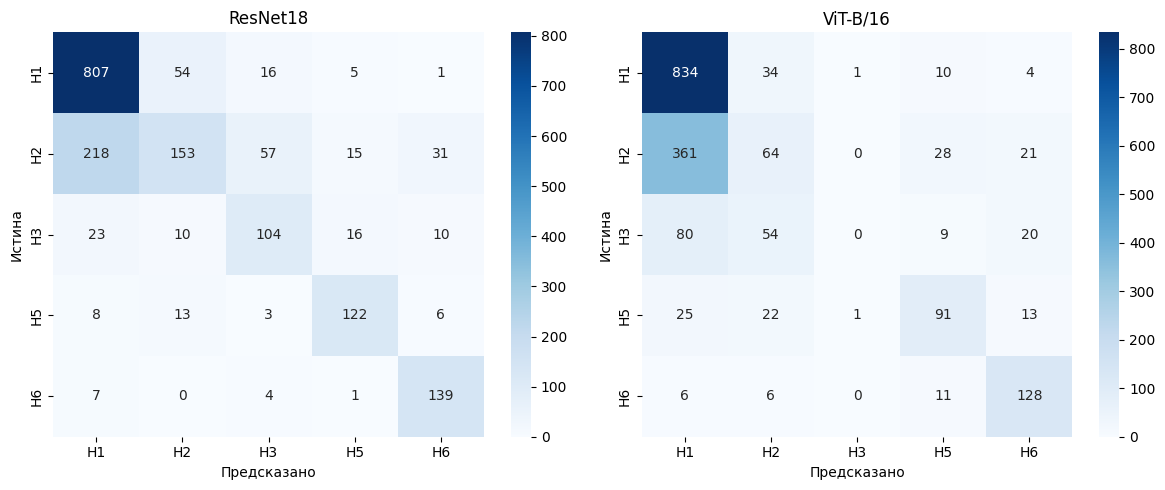

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title(f'ResNet18')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истина')

sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title(f'ViT-B/16')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истина')

plt.tight_layout()
plt.show()

Матрица ошибок ResNet18 показывает основное затруднения с классом H3, который модель часто путает с H1 и другими категориями, а классы H1 и H6 распознаются достаточно уверенно. ViT‑B/16 обучался медленно, его loss остался высоким даже на пятой эпохе, а матрица ошибок показывает сильный дисбаланс, класс H3, был проигнорирован, а класс H2 часто путается с H1, что привело к резкому падению F1‑macro. Эта модель требует большего количества данных или более тщательной настройки гиперпараметров для эффективного обучения. Таким образом, ResNet18 оказался предпочтительнее.

## 3. Улучшение бейзлайна

**Гипотезы**  

- Гипотеза 1: Увеличение числа эпох обучения до 10 с Early Stopping

- Гипотеза 2: Оптимизация аугментаций для микроскопии. Добавим ColorJitter(brightness=0.2, contrast=0.2)

- Гипотеза 3: Замена планировщика StepLR на CosineAnnealingLR

- Гипотеза 4: Для ResNet18 размораживаем слои layer3 и layer4, lr = 1e-4. Для ViT размораживаем последние 2 блока трансформера, lr = 1e-5. Используем gradient clipping (0.5)

Трансформы для обучения с новыми аугментациями (гипотеза 2)

In [16]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

Функция для разморозки слоёв (Гипотеза 4)

In [17]:
def unfreeze_layers(model, model_name):
    if model_name == "resnet18":
        for name, param in model.named_parameters():
            if "layer3" in name or "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        backbone_lr = 1e-4
        head_lr = 1e-3

    elif model_name == "vit_b_16":
        for name, param in model.named_parameters():
            if "encoder.layers.10" in name or "encoder.layers.11" in name or "heads" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        backbone_lr = 1e-5
        head_lr = 1e-4

    return backbone_lr, head_lr

train_baseline с Early Stopping, CosineAnnealingLR и gradient clipping (Гипотезы 1, 3, 4)

In [18]:
import copy

def train_baseline(model, model_name, train_loader, val_loader, epochs=10, lr=1e-3, patience=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    backbone_lr, head_lr = unfreeze_layers(model, model_name)

    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            if "fc" in name or "heads" in name:
                head_params.append(param)
            else:
                backbone_params.append(param)

    optimizer = optim.Adam([
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': head_params, 'lr': head_lr}
    ])

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    no_improve_epochs = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        scheduler.step()
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels.to(device)).sum().item()
        val_acc = correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(f"Early stopping на эпохе {epoch+1}")
                break

    model.load_state_dict(best_weights)
    print(f"Лучшая точность на валидации: {best_acc:.4f}")
    return model

Запуск обучения улучшенных моделей

In [19]:
print("\nResNet18 улучшенная")
resnet_imp = get_model("resnet18", num_classes)
resnet_imp = train_baseline(resnet_imp, "resnet18", train_loader, val_loader, epochs=10)


ResNet18 улучшенная
Epoch 1/10 | Loss: 0.8223 | Val Acc: 0.7608
Epoch 2/10 | Loss: 0.6721 | Val Acc: 0.7340
Epoch 3/10 | Loss: 0.6097 | Val Acc: 0.8053
Epoch 4/10 | Loss: 0.5479 | Val Acc: 0.8239
Epoch 5/10 | Loss: 0.4900 | Val Acc: 0.8201
Epoch 6/10 | Loss: 0.4565 | Val Acc: 0.8519
Epoch 7/10 | Loss: 0.4139 | Val Acc: 0.8579
Epoch 8/10 | Loss: 0.3916 | Val Acc: 0.8618
Epoch 9/10 | Loss: 0.3666 | Val Acc: 0.8711
Epoch 10/10 | Loss: 0.3399 | Val Acc: 0.8727
Лучшая точность на валидации: 0.8727


In [20]:
print("\nViT-B/16 улучшенная")
vit_imp = get_model("vit_b_16", num_classes)
vit_imp = train_baseline(vit_imp, "vit_b_16", train_loader, val_loader, epochs=10)


ViT-B/16 улучшенная
Epoch 1/10 | Loss: 1.2202 | Val Acc: 0.5946
Epoch 2/10 | Loss: 1.0207 | Val Acc: 0.6511
Epoch 3/10 | Loss: 0.9489 | Val Acc: 0.6725
Epoch 4/10 | Loss: 0.9100 | Val Acc: 0.6807
Epoch 5/10 | Loss: 0.8824 | Val Acc: 0.6906
Epoch 6/10 | Loss: 0.8737 | Val Acc: 0.6983
Epoch 7/10 | Loss: 0.8648 | Val Acc: 0.7010
Epoch 8/10 | Loss: 0.8514 | Val Acc: 0.6999
Epoch 9/10 | Loss: 0.8483 | Val Acc: 0.7021
Epoch 10/10 | Loss: 0.8467 | Val Acc: 0.7016
Лучшая точность на валидации: 0.7021


Оценка качества

In [22]:
acc_rn_imp, f1_rn_imp, cm_rn_imp, _, _ = compute_metrics(resnet_imp, val_loader, DEVICE, classes)
acc_vit_imp, f1_vit_imp, cm_vit_imp, _, _ = compute_metrics(vit_imp, val_loader, DEVICE, classes)

print(f"ResNet18 улучшенная. Accuracy: {acc_rn_imp:.4f}, F1-macro: {f1_rn_imp:.4f}")
print(f"ViT-B/16 улучшенная. Accuracy: {acc_vit_imp:.4f}, F1-macro: {f1_vit_imp:.4f}")

ResNet18 улучшенная. Accuracy: 0.8727, F1-macro: 0.8898
ViT-B/16 улучшенная. Accuracy: 0.7021, F1-macro: 0.6792


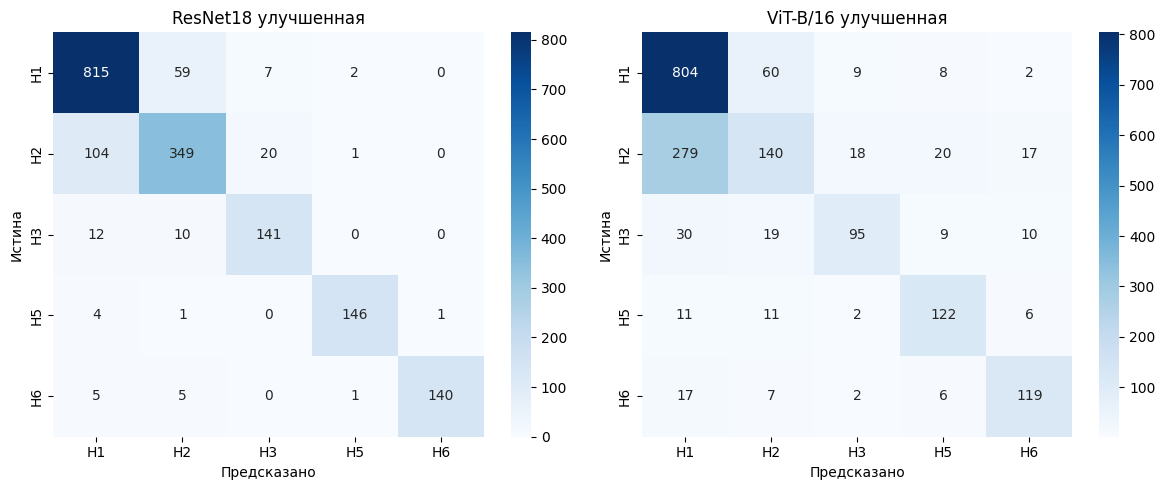

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_rn_imp, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title(f'ResNet18 улучшенная')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истина')

sns.heatmap(cm_vit_imp, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title(f'ViT-B/16 улучшенная')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истина')

plt.tight_layout()
plt.show()

Улучшенный бейзлайн повысил качество обеих моделей. ResNet18 улучшенная достигла точности 87.3 и F1‑macro 0.89, что на 14.5 выше базовой версии. Хороший результат. матрица ошибок показывает, что теперь все классы, включая ранее проблемные H3 и H5, распознаются уверенно. ViT‑B/16 улучшенная также прибавила, точность выросла с 61.3 до 70.2, F1‑macro с 0.46 до 0.68, однако всё ещё заметно уступает ResNet18 и продолжает путать H2 с H1.

Гипотезы оказались эффективными: ResNet18 практически вышел на наилучший возможный результат, и дальнейшее обучение вряд ли даст значимый прирост, а для ViT можно было бы попробовать ещё 5–10 эпох, но текущий результат уже является хорошим улучшенным бейзлайном. Таким образом, ResNet18 показал себя как более стабильная и точная архитектура для классификации микроскопических грибов, и именно её можно рекомендовать в качестве основы для дальнейшей оптимизации.

## 4. Имплементация алгоритма машинного обучения

Моя реализация сверточной модели

In [27]:
import torch.nn.functional as F

In [24]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.pool  = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(128)

        self.fc1   = nn.Linear(128 * 14 * 14, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [25]:
# Функция обучения
def train_custom(model, train_loader, val_loader, epochs=5, lr=1e-3, device=DEVICE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    best_acc = 0.0
    best_weights = model.state_dict().copy()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        scheduler.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels.to(device)).sum().item()
        val_acc = correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = model.state_dict().copy()

    model.load_state_dict(best_weights)
    print(f"Лучшая точность на валидации: {best_acc:.4f}")
    return model

Обучение, результаты и сравнение с базовой моделью

In [28]:
print("\nCustomCNN моя реализация")
custom_cnn = CustomCNN(num_classes=num_classes)
custom_cnn = train_custom(custom_cnn, train_loader, val_loader, epochs=5)


CustomCNN моя реализация
Epoch 1/5 | Loss: 1.4441 | Val Acc: 0.6171
Epoch 2/5 | Loss: 1.0470 | Val Acc: 0.6133
Epoch 3/5 | Loss: 1.0281 | Val Acc: 0.6122
Epoch 4/5 | Loss: 0.9645 | Val Acc: 0.6347
Epoch 5/5 | Loss: 0.9404 | Val Acc: 0.6577
Лучшая точность на валидации: 0.6577


In [29]:
acc_cnn, f1_cnn, cm_cnn, _, _ = compute_metrics(custom_cnn, val_loader, DEVICE, classes)
print(f"CustomCNN. Accuracy: {acc_cnn:.4f}, F1-macro: {f1_cnn:.4f}")

CustomCNN. Accuracy: 0.6577, F1-macro: 0.5618


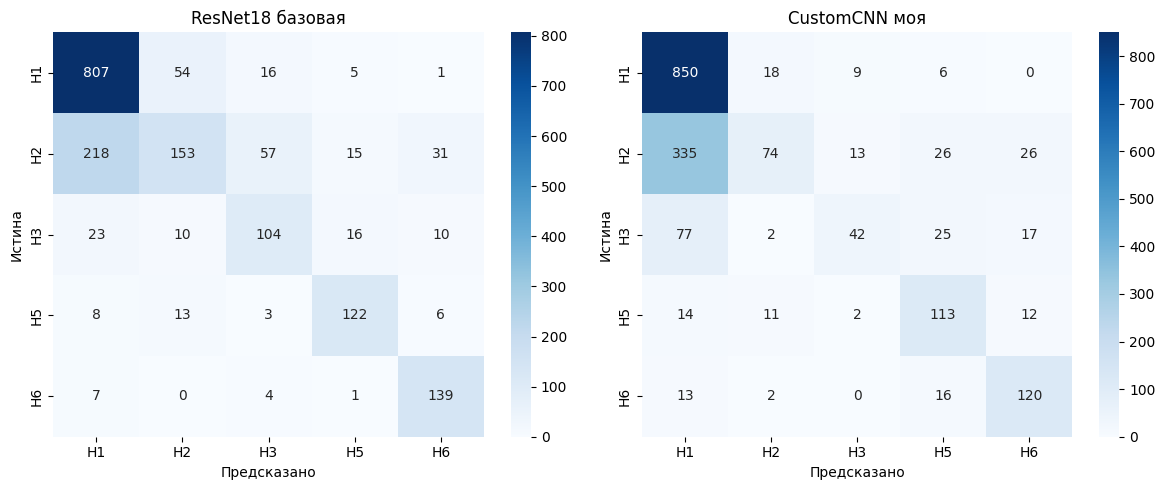

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_rn, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title(f'ResNet18 базовая')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истина')

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title(f'CustomCNN моя')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истина')

plt.tight_layout()
plt.show()

In [31]:
print("\nСравнение CustomCNN с базовым ResNet18")
print(f"ResNet18: Acc={acc_rn:.4f}, F1={f1_rn:.4f}")
print(f"CustomCNN: Acc={acc_cnn:.4f}, F1={f1_cnn:.4f}")


Сравнение CustomCNN с базовым ResNet18
ResNet18: Acc=0.7268, F1=0.6941
CustomCNN: Acc=0.6577, F1=0.5618


Моя реализация свёрточной сети показала точность 65.8 и F1‑macro 0.562, что  ниже результатов базового ResNet18, 72.7% и 0.694. Это ожидаемо, так как ResNet18 использует более глубокую архитектуру с остаточными связями. Матрица ошибок подтверждает, что моя реализация хуже справляется с классами H2 и H3, чаще путая их с H1. Можно сказать, что моя модель показывает устойчивое обучение и достигает приемлемого уровня точности для сети, реализованной самостоятельно.


Моя реализация трансформерной модели

In [33]:
import math

In [34]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=384):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, D)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, int(embed_dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(int(embed_dim * mlp_ratio), embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class CustomViT(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, num_classes=5,
                 embed_dim=384, depth=6, num_heads=6, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.patch_embed.num_patches, embed_dim))
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, dropout=dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        x = x[:, 0]
        x = self.head(x)
        return x

Обучение, результаты и сравнение с базовой моделью

In [35]:
print("\nCustomViT моя реализация")
custom_vit = CustomViT(img_size=IMG_SIZE, num_classes=num_classes)
custom_vit = train_custom(custom_vit, train_loader, val_loader, epochs=5)


CustomViT моя реализация
Epoch 1/5 | Loss: 1.2306 | Val Acc: 0.5743
Epoch 2/5 | Loss: 1.0636 | Val Acc: 0.5963
Epoch 3/5 | Loss: 1.0049 | Val Acc: 0.5749
Epoch 4/5 | Loss: 0.9609 | Val Acc: 0.6182
Epoch 5/5 | Loss: 0.9173 | Val Acc: 0.6478
Лучшая точность на валидации: 0.6478


In [36]:
acc_cvit, f1_cvit, cm_cvit, _, _ = compute_metrics(custom_vit, val_loader, DEVICE, classes)
print(f"CustomViT. Accuracy: {acc_cvit:.4f}, F1-macro: {f1_cvit:.4f}")

CustomViT. Accuracy: 0.6478, F1-macro: 0.5634


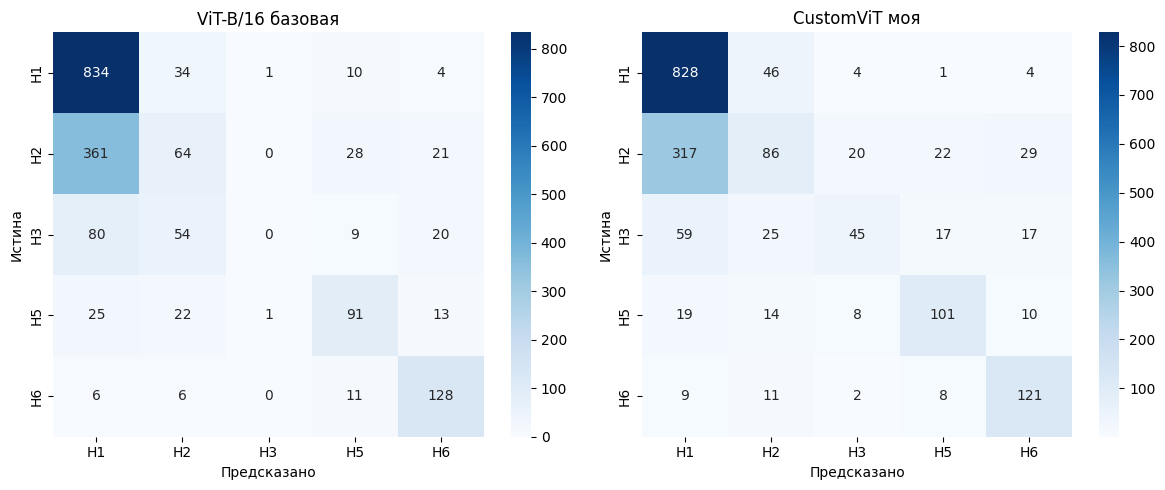

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_vit, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title(f'ViT-B/16 базовая')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истина')

sns.heatmap(cm_cvit, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title(f'CustomViT моя')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истина')

plt.tight_layout()
plt.show()

In [38]:
print("\nСравнение CustomViT с базовой ViT-B/16")
print(f"ViT-B/16: Acc={acc_vit:.4f}, F1={f1_vit:.4f}")
print(f"CustomViT: Acc={acc_cvit:.4f}, F1={f1_cvit:.4f}")


Сравнение CustomViT с базовой ViT-B/16
ViT-B/16: Acc=0.6127, F1=0.4644
CustomViT: Acc=0.6478, F1=0.5634


Моя реализация трансформерной модели показала точность 64.8 и F1‑macro 0.563, что оказалось выше, чем у базового предобученного ViT‑B/16 61.3 и 0.464. Это можно объяснить тем, что моя облегчённая архитектура с меньшим числом параметров быстрее сошлась на ограниченном датасете, а большой ViT‑B/16 требовал больше эпох и данных. Матрица ошибок подтверждает, что CustomViT лучше различает классы H2 и H3, хотя всё ещё путает их с H1. В целом моя реализация работает корректно и даже превзошла библиотечную модель, что круто.

**Добавляю техники из улучшенного бейзлайна в собственные реализации моделей**

Гипотеза 4 не применяется, так как CustomCNN и CustomViT обучаются с нуля, у них нет предобученных слоёв

Моя реализация обучения с улучшениями

In [39]:
def train_custom_improved(model, train_loader, val_loader, epochs=10, lr=1e-3, patience=3, device=DEVICE):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = 0.0
    best_weights = model.state_dict().copy()
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        scheduler.step()

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels.to(device)).sum().item()
        val_acc = correct / len(val_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = model.state_dict().copy()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping на эпохе {epoch+1}")
                break

    model.load_state_dict(best_weights)
    print(f"Лучшая точность на валидации: {best_acc:.4f}")
    return model

Обучение, результаты и сравнение с базовой моделью (сверточной)

In [40]:
print("\nCustomCNN улучшенная")
custom_cnn_imp = CustomCNN(num_classes=num_classes)
custom_cnn_imp = train_custom_improved(custom_cnn_imp, train_loader, val_loader, epochs=10)


CustomCNN улучшенная
Epoch 1/10 | Loss: 1.6207 | Val Acc: 0.6089
Epoch 2/10 | Loss: 1.0454 | Val Acc: 0.6177
Epoch 3/10 | Loss: 1.0209 | Val Acc: 0.6127
Epoch 4/10 | Loss: 1.0016 | Val Acc: 0.6314
Epoch 5/10 | Loss: 0.9825 | Val Acc: 0.6374
Epoch 6/10 | Loss: 0.9581 | Val Acc: 0.6500
Epoch 7/10 | Loss: 0.9391 | Val Acc: 0.6478
Epoch 8/10 | Loss: 0.9143 | Val Acc: 0.6615
Epoch 9/10 | Loss: 0.8979 | Val Acc: 0.6665
Epoch 10/10 | Loss: 0.8850 | Val Acc: 0.6786
Лучшая точность на валидации: 0.6786


In [41]:
acc_cnn_imp, f1_cnn_imp, cm_cnn_imp, _, _ = compute_metrics(custom_cnn_imp, val_loader, DEVICE, classes)
print(f"CustomCNN улучшенная. Accuracy: {acc_cnn_imp:.4f}, F1-macro: {f1_cnn_imp:.4f}")

CustomCNN улучшенная. Accuracy: 0.6786, F1-macro: 0.6212


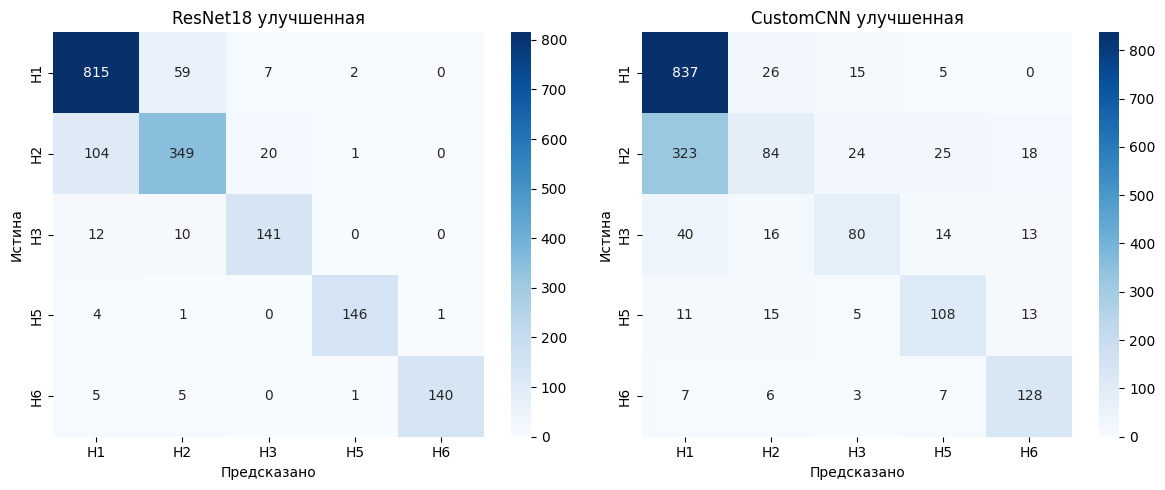

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_rn_imp, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title(f'ResNet18 улучшенная')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истина')

sns.heatmap(cm_cnn_imp, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title(f'CustomCNN улучшенная')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истина')

plt.tight_layout()
plt.show()

In [43]:
print("\nСравнение улучшенных моделей")
print(f"ResNet18 улучшенная: Acc={acc_rn_imp:.4f}, F1={f1_rn_imp:.4f}")
print(f"CustomCNN улучшенная: Acc={acc_cnn_imp:.4f}, F1={f1_cnn_imp:.4f}")


Сравнение улучшенных моделей
ResNet18 улучшенная: Acc=0.8727, F1=0.8898
CustomCNN улучшенная: Acc=0.6786, F1=0.6212


Улучшенная CustomCNN показала точность 67.9 и F1‑macro 0.62, что на 2.2 выше базовой версии, но значительно уступает улучшенному ResNet18 87.3. Это ожидаемо, так как предобученная ResNet18 использует веса ImageNet и глубокую архитектуру, тогда как моя сеть обучалась с нуля. Матрица ошибок подтверждает, что CustomCNN стала лучше различать классы, но всё ещё сильно путает H2 с H1. Тем не менее, применение гипотез дало положительный эффект.

Обучение, результаты и сравнение с базовой моделью (трансформерной)

In [44]:
print("\nCustomViT улучшенная")
custom_vit_imp = CustomViT(img_size=IMG_SIZE, num_classes=num_classes)
custom_vit_imp = train_custom_improved(custom_vit_imp, train_loader, val_loader, epochs=10)


CustomViT улучшенная
Epoch 1/10 | Loss: 1.1948 | Val Acc: 0.5315
Epoch 2/10 | Loss: 1.0500 | Val Acc: 0.5656
Epoch 3/10 | Loss: 1.0223 | Val Acc: 0.6100
Epoch 4/10 | Loss: 0.9776 | Val Acc: 0.6116
Epoch 5/10 | Loss: 0.9473 | Val Acc: 0.6352
Epoch 6/10 | Loss: 0.9282 | Val Acc: 0.6221
Epoch 7/10 | Loss: 0.9030 | Val Acc: 0.6314
Epoch 8/10 | Loss: 0.8658 | Val Acc: 0.6594
Epoch 9/10 | Loss: 0.8290 | Val Acc: 0.6621
Epoch 10/10 | Loss: 0.8319 | Val Acc: 0.6665
Лучшая точность на валидации: 0.6665


In [45]:
acc_cvit_imp, f1_cvit_imp, cm_cvit_imp, _, _ = compute_metrics(custom_vit_imp, val_loader, DEVICE, classes)
print(f"CustomViT улучшенная. Accuracy: {acc_cvit_imp:.4f}, F1-macro: {f1_cvit_imp:.4f}")

CustomViT улучшенная. Accuracy: 0.6665, F1-macro: 0.6115


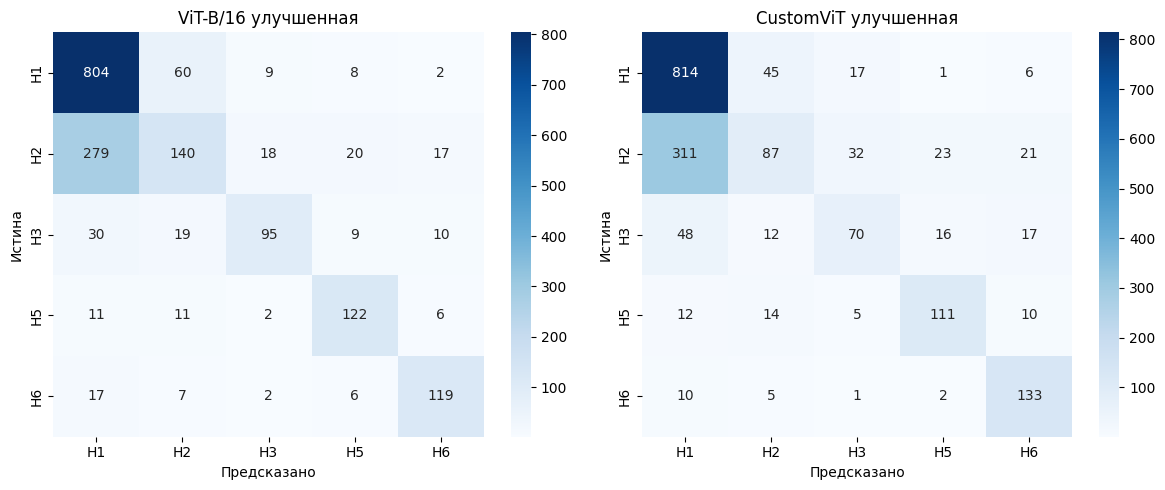

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_vit_imp, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title(f'ViT-B/16 улучшенная')
axes[0].set_xlabel('Предсказано')
axes[0].set_ylabel('Истина')

sns.heatmap(cm_cvit_imp, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title(f'CustomViT улучшенная')
axes[1].set_xlabel('Предсказано')
axes[1].set_ylabel('Истина')

plt.tight_layout()
plt.show()

In [47]:
print("\nСравнение улучшенных моделей")
print(f"ViT-B/16 улучшенная: Acc={acc_vit_imp:.4f}, F1={f1_vit_imp:.4f}")
print(f"CustomViT улучшенная: Acc={acc_cvit_imp:.4f}, F1={f1_cvit_imp:.4f}")


Сравнение улучшенных моделей
ViT-B/16 улучшенная: Acc=0.7021, F1=0.6792
CustomViT улучшенная: Acc=0.6665, F1=0.6115


Улучшенная CustomViT достигла точности 66.7 и F1‑macro 0.612, что на 1.9 выше базовой версии, 64.8, но всё ещё уступает улучшенному библиотечному ViT‑B/16 70.2. Это можно объяснить тем, что CustomViT обучалась с нуля, без предобученных весов, в отличие от ViT‑B/16. Применение гипотез дало положительный эффект: модель стала лучше различать классы, хотя путаница между H2 и H1 сохраняется. Результаты подтверждают, что самостоятельная реализация трансформера работает корректно и способна улучшаться при оптимизации процесса обучения.